In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FraudDetection") \
    .getOrCreate()

spark


25/12/30 17:02:08 WARN Utils: Your hostname, DESKTOP-DD5N9SQ resolves to a loopback address: 127.0.1.1; using 172.17.138.117 instead (on interface eth0)
25/12/30 17:02:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/souhail/.local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/souhail/.ivy2/cache
The jars for the packages stored in: /home/souhail/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-aa7f8e04-00be-4d57-9f8f-747ca89b7c7a;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.4.1 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.4.1 in central
	found org.apache.kafka#kafka-clients;3.3.2 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.1 in central
	found org.slf4j#slf4j-api;2.0.6 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
:: resolution report :: resolve 2044ms :: artifacts dl 81ms


In [2]:
df = spark.read.csv("../dataset/creditcard.csv", header=True, inferSchema=True)

In [3]:
df.show(5)


25/12/30 17:03:18 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|                V22|     

In [4]:
# Convertir en Pandas (attention si le dataset est très grand !)
import pandas as pd

data_pd = df.limit(5).toPandas()
display(data_pd)  # si tu es dans Jupyter Notebook

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
class_counts = df.groupBy("Class").count().toPandas()
class_counts


,Class,count
0,1,492
1,0,284315


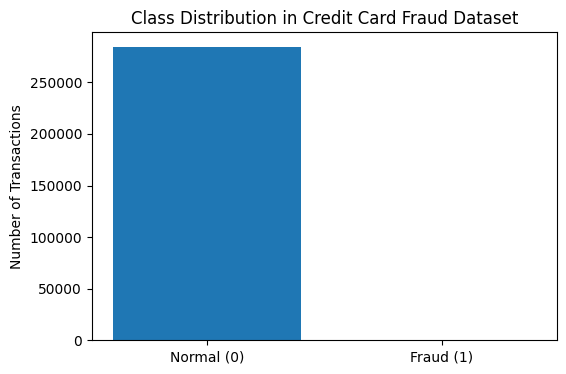

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(class_counts["Class"], class_counts["count"])
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Number of Transactions")
plt.title("Class Distribution in Credit Card Fraud Dataset")
plt.show()


In [7]:
from pyspark.sql.functions import when, col

# Séparer les classes
df_class_0 = df.filter(col("Class") == 0)
df_class_1 = df.filter(col("Class") == 1)

# 1. Sous-échantillonnage léger de la classe 0 (par exemple 50% des normaux)
df_class_0_sampled = df_class_0.sample(withReplacement=False, fraction=0.4, seed=42)

# 2. Sur-échantillonnage de la classe 1 (par exemple multiplier par 10 pour augmenter les fraudes)
df_class_1_oversampled = df_class_1.sample(withReplacement=True, fraction=15.0, seed=42)

# 3. Combiner les deux classes pour créer un dataset plus équilibré
df_combined = df_class_0_sampled.union(df_class_1_oversampled)

   Class   count
0      0  113661
1      1    7491


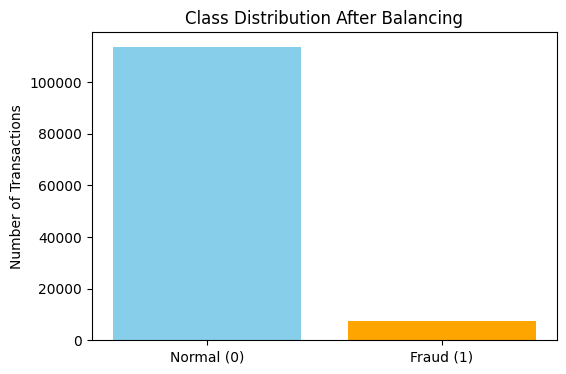

In [8]:
# 1. Count new class distribution
class_counts_balanced = df_combined.groupBy("Class").count().toPandas()
print(class_counts_balanced)

# 2. Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(class_counts_balanced["Class"], class_counts_balanced["count"], color=["skyblue", "orange"])
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Number of Transactions")
plt.title("Class Distribution After Balancing")
plt.show()


In [9]:
# 4. Calculer les poids dans ce nouveau dataset
total_count = df_combined.count()
count_class_0 = df_combined.filter(col("Class") == 0).count()
count_class_1 = df_combined.filter(col("Class") == 1).count()

weight_0 = total_count / (2 * count_class_0)
weight_1 = total_count / (2 * count_class_1)

# 5. Ajouter la colonne 'weight'
df_combined_weighted = df_combined.withColumn("weight", when(col("Class") == 0, weight_0).otherwise(weight_1))

In [10]:
# Convert Spark DataFrame to Pandas (small subset)
df_pd = df_combined_weighted.toPandas()  # no need to select columns again

# Afficher 2 exemples de transactions normales (classe 0)
print("Exemples de transactions normales (classe 0) :")
print(df_pd[df_pd["Class"] == 0].head(2))

# Afficher 2 exemples de transactions frauduleuses (classe 1)
print("Exemples de transactions frauduleuses (classe 1) :")
print(df_pd[df_pd["Class"] == 1].head(2))


Exemples de transactions normales (classe 0) :
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
1   7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118  1.120631   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
1 -3.807864  0.615375  ... -1.015455  0.057504 -0.649709 -0.415267 -0.051634   

        V27       V28  Amount  Class    weight  
0  0.062723  0.061458   123.5      0  0.532953  
1 -1.206921 -1.085339    40.8      0  0.532953  

[2 rows x 32 columns]
Exemples de transactions frauduleuses (classe 1) :
         Time        V1        V2        V3        V4        V5        V6  \
113661  406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
113662  406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   

              V

In [15]:
from pyspark.ml.feature import VectorAssembler

# List of feature columns
feature_cols = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"] 

# Create the VectorAssembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Apply it to the DataFrame
df_features = assembler.transform(df_combined_weighted).select("features", "Class","weight")

# Show example
df_features_pd = df_features.limit(5).toPandas()
display(df_features_pd) 


,features,Class,weight
0,"[1.0, -0.966271711572087, -0.185226008082898, ...",0,0.532953
1,"[7.0, -0.644269442348146, 1.41796354547385, 1....",0,0.532953
2,"[10.0, 1.249998742053, -1.22163680921816, 0.38...",0,0.532953
3,"[12.0, 1.10321543528383, -0.0402962145973447, ...",0,0.532953
4,"[14.0, -5.40125766315825, -5.45014783420644, 1...",0,0.532953


In [16]:
df_fe = df_features.toPandas()

# Afficher 2 exemples de transactions normales (classe 0)
print("Exemples de transactions normales (classe 0) :")
print(df_fe[df_fe["Class"] == 0].head(2))

# Afficher 2 exemples de transactions frauduleuses (classe 1)
print("Exemples de transactions frauduleuses (classe 1) :")
print(df_fe[df_fe["Class"] == 1].head(2))


Exemples de transactions normales (classe 0) :
                                            features  Class    weight
0  [1.0, -0.966271711572087, -0.185226008082898, ...      0  0.532953
1  [7.0, -0.644269442348146, 1.41796354547385, 1....      0  0.532953
Exemples de transactions frauduleuses (classe 1) :
                                                 features  Class    weight
113661  [406.0, -2.3122265423263, 1.95199201064158, -1...      1  8.086504
113662  [406.0, -2.3122265423263, 1.95199201064158, -1...      1  8.086504


In [17]:
# Split fractions: 70% train, 15% validation, 15% test
train_df, val_df, test_df = df_features.randomSplit([0.7, 0.15, 0.15], seed=42)

# Check the counts
print(f"Train: {train_df.count()}, Validation: {val_df.count()}, Test: {test_df.count()}")


[Stage 42:====================================>                     (5 + 3) / 8]

Train: 85022, Validation: 18146, Test: 17984


In [18]:
# Save test_df as JSON (recommended for Kafka)
test_df.write.mode("overwrite").json("../stream_data/test_transactions")


# random forest

In [16]:
from pyspark.ml.classification import RandomForestClassifier


In [17]:
rf = RandomForestClassifier(
    featuresCol="features",   # the vector of features
    labelCol="Class",         # the target
    weightCol="weight",       # handle imbalanced dataset
    numTrees=100,             # number of trees
    maxDepth=5,               # depth of each tree
    seed=42
)


In [18]:
# Train the model
rf_model = rf.fit(train_df)


In [19]:
# Make predictions
predictions_val = rf_model.transform(val_df)

# Show first 5 predictions
predictions_val.select("features", "Class", "prediction", "probability").show(5, truncate=False)


[Stage 49:>                                                         (0 + 1) / 1]

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+----------------------------------------+
|features                                                                                                                                                                                                                                                                                                                                                                                                               

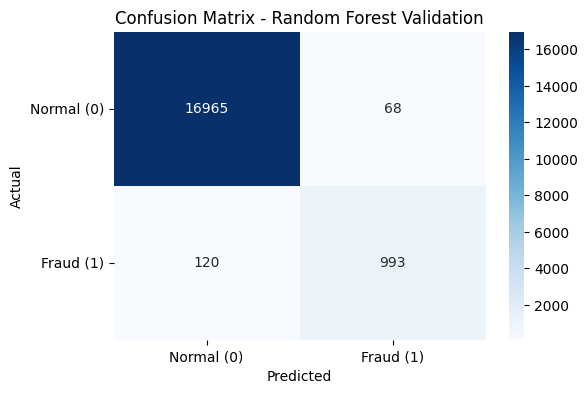

In [20]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Select true labels and predictions, convert to Pandas
preds_pd = predictions_val.select("Class", "prediction").toPandas()

# 2. Compute confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(preds_pd["Class"], preds_pd["prediction"])

# 3. Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Validation")
plt.xticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.show()


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert Spark predictions to Pandas (if not already)
preds_pd = predictions_val.select("Class", "prediction").toPandas()

# Compute metrics
accuracy = accuracy_score(preds_pd["Class"], preds_pd["prediction"])
precision = precision_score(preds_pd["Class"], preds_pd["prediction"])
recall = recall_score(preds_pd["Class"], preds_pd["prediction"])
f1 = f1_score(preds_pd["Class"], preds_pd["prediction"])

# Print results
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.9896
Precision: 0.9359
Recall   : 0.8922
F1-score : 0.9135


In [22]:
# Predictions on training set
preds_train = rf_model.transform(train_df)
preds_train_pd = preds_train.select("Class", "prediction").toPandas()

# Predictions on validation set
preds_val_pd = predictions_val.select("Class", "prediction").toPandas()

from sklearn.metrics import f1_score

f1_train = f1_score(preds_train_pd["Class"], preds_train_pd["prediction"])
f1_val = f1_score(preds_val_pd["Class"], preds_val_pd["prediction"])

print(f"F1-score Train: {f1_train:.4f}")
print(f"F1-score Validation: {f1_val:.4f}")


F1-score Train: 0.9234
F1-score Validation: 0.9135


In [63]:
# Import Spark ML class (if not already)
from pyspark.ml.classification import RandomForestClassificationModel

# Define folder path
rf_model_folder = "./models/random_forest_model"

# Save the model
rf_model.write().overwrite().save(rf_model_folder)

print(f"Random Forest model saved successfully at: {rf_model_folder}")


Random Forest model saved successfully at: ./models/random_forest_model


# XGBoost

In [19]:
import numpy as np

# Training set
train_pd = train_df.toPandas()
X_train = np.vstack(train_pd["features"].values)
y_train = train_pd["Class"].values
w_train = train_pd["weight"].values

# Validation set
val_pd = val_df.toPandas()
X_val = np.vstack(val_pd["features"].values)
y_val = val_pd["Class"].values
w_val = val_pd["weight"].values

# Test set
test_pd = test_df.toPandas()
X_test = np.vstack(test_pd["features"].values)
y_test = test_pd["Class"].values
w_test = test_pd["weight"].values

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (85022, 30)
Validation shape: (18146, 30)
Test shape: (17984, 30)


In [25]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
from xgboost import XGBClassifier

# Define the model
xgb_model = XGBClassifier(
    n_estimators=200,    # number of trees
    max_depth=5,         # depth of each tree
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model with weights
xgb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=True)


/home/souhail/.local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [17:26:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.61259
[1]	validation_0-logloss:0.54305
[2]	validation_0-logloss:0.48402
[3]	validation_0-logloss:0.43470
[4]	validation_0-logloss:0.39129
[5]	validation_0-logloss:0.35362
[6]	validation_0-logloss:0.32214
[7]	validation_0-logloss:0.29319
[8]	validation_0-logloss:0.26725
[9]	validation_0-logloss:0.24566
[10]	validation_0-logloss:0.22533
[11]	validation_0-logloss:0.20714
[12]	validation_0-logloss:0.19103
[13]	validation_0-logloss:0.17661
[14]	validation_0-logloss:0.16348
[15]	validation_0-logloss:0.15205
[16]	validation_0-logloss:0.14104
[17]	validation_0-logloss:0.13180
[18]	validation_0-logloss:0.12289
[19]	validation_0-logloss:0.11528
[20]	validation_0-logloss:0.10881
[21]	validation_0-logloss:0.10233
[22]	validation_0-logloss:0.09672
[23]	validation_0-logloss:0.09118
[24]	validation_0-logloss:0.08638
[25]	validation_0-logloss:0.08205
[26]	validation_0-logloss:0.07819
[27]	validation_0-logloss:0.07472
[28]	validation_0-logloss:0.07107
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Accuracy globale : 0.9994
Precision globale: 0.9911
Recall global   : 1.0000
F1-score global : 0.9955

Métriques par classe :
Classe 0 -> Precision: 1.0000, Recall: 0.9994, F1-score: 0.9997
Classe 1 -> Precision: 0.9911, Recall: 1.0000, F1-score: 0.9955


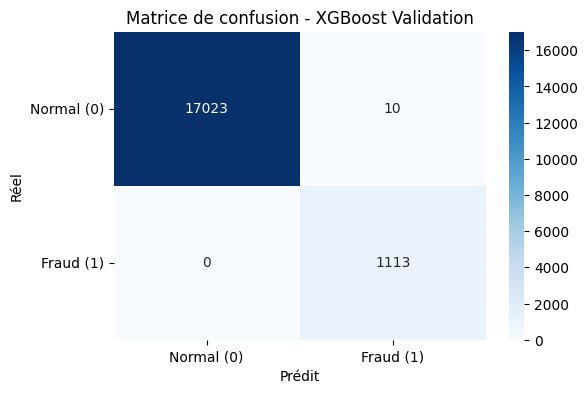

In [21]:
# Imports nécessaires
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Prédictions sur le set de validation
y_val_pred = xgb_model.predict(X_val)

# Metrics globales
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Accuracy globale : {accuracy:.4f}")
print(f"Precision globale: {precision:.4f}")
print(f"Recall global   : {recall:.4f}")
print(f"F1-score global : {f1:.4f}")

# Metrics par classe
precision_per_class = precision_score(y_val, y_val_pred, average=None)
recall_per_class = recall_score(y_val, y_val_pred, average=None)
f1_per_class = f1_score(y_val, y_val_pred, average=None)

print("\nMétriques par classe :")
for i, cls in enumerate([0,1]):
    print(f"Classe {cls} -> Precision: {precision_per_class[i]:.4f}, Recall: {recall_per_class[i]:.4f}, F1-score: {f1_per_class[i]:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - XGBoost Validation")
plt.xticks([0.5,1.5], ["Normal (0)","Fraud (1)"])
plt.yticks([0.5,1.5], ["Normal (0)","Fraud (1)"], rotation=0)
plt.show()


In [22]:
# Predictions on training set
y_train_pred = xgb_model.predict(X_train)

# Compute F1 on training
f1_train = f1_score(y_train, y_train_pred)
f1_val = f1_score(y_val, y_val_pred)

print(f"F1-score Train: {f1_train:.4f}")
print(f"F1-score Validation: {f1_val:.4f}")


F1-score Train: 0.9990
F1-score Validation: 0.9955


In [23]:
import joblib
import os
# Define folder path
model_folder = "../models"

# Define model path
model_path = os.path.join(model_folder, "xgboost_fraud_model2.pkl")

# Save the model
joblib.dump(xgb_model, model_path)

print(f"Model saved successfully at: {model_path}")


Model saved successfully at: ../models/xgboost_fraud_model2.pkl


In [67]:
import os

model_folder = "./models/random_forest_model"

if os.path.exists(model_folder):
    print("Random Forest model folder exists!")
    print("Contents:", os.listdir(model_folder))
else:
    print("Model folder not found!")


Random Forest model folder exists!
Contents: ['data', 'treesMetadata', 'metadata']


# Decision Tree

In [28]:
from pyspark.ml.classification import DecisionTreeClassifier


In [29]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="Class",
    weightCol="weight",
    maxDepth=5,        # limit depth to reduce overfitting
    seed=42
)

In [30]:
dt_model = dt.fit(train_df)


In [31]:
val_pred_dt = dt_model.transform(val_df)

In [32]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


In [33]:
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_dt = evaluator_f1.evaluate(val_pred_dt)
precision_dt = evaluator_precision.evaluate(val_pred_dt)
recall_dt = evaluator_recall.evaluate(val_pred_dt)

print(f"Decision Tree — Validation metrics")
print(f"F1-score : {f1_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")


[Stage 78:=============================>                            (4 + 4) / 8]

Decision Tree — Validation metrics
F1-score : 0.9749
Precision: 0.9791
Recall   : 0.9731


In [34]:
# Predictions on training data
train_pred_dt = dt_model.transform(train_df)


In [35]:
# F1
f1_train_dt = evaluator_f1.evaluate(train_pred_dt)

# Precision
precision_train_dt = evaluator_precision.evaluate(train_pred_dt)

# Recall
recall_train_dt = evaluator_recall.evaluate(train_pred_dt)

print("Decision Tree — Train metrics")
print(f"F1-score : {f1_train_dt:.4f}")
print(f"Precision: {precision_train_dt:.4f}")
print(f"Recall   : {recall_train_dt:.4f}")


[Stage 84:===========================================>              (6 + 2) / 8]

Decision Tree — Train metrics
F1-score : 0.9751
Precision: 0.9791
Recall   : 0.9733


In [36]:
from pyspark.sql.functions import col
confusion_matrix_dt = (
    val_pred_dt
    .groupBy("Class", "prediction")
    .count()
    .orderBy("Class", "prediction")
)

confusion_matrix_dt.show()


[Stage 86:===========================================>              (6 + 2) / 8]

+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0|16598|
|    0|       1.0|  435|
|    1|       0.0|   54|
|    1|       1.0| 1059|
+-----+----------+-----+



In [38]:
# Convert Spark predictions to Pandas
dt_val_pd = val_pred_dt.select("Class", "prediction").toPandas()


In [39]:
y_true = dt_val_pd["Class"]
y_pred = dt_val_pd["prediction"]


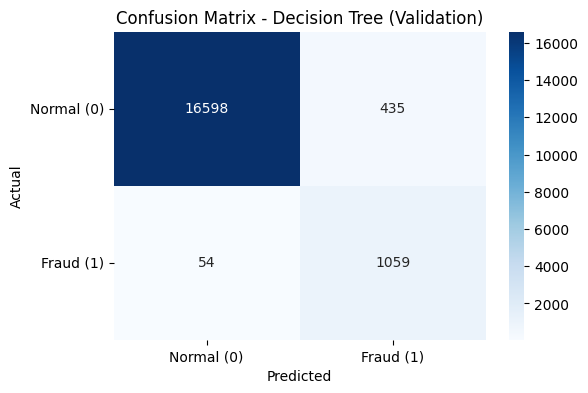

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Validation)")

plt.xticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"], rotation=0)

plt.show()


In [49]:
import os 

# Define folder path for models
model_folder = "../models"
dt_model_path = os.path.join(model_folder, "decision_tree_fraud_model_1")

# Save the Spark Decision Tree model
dt_model.save(dt_model_path)

print(f"Decision Tree model saved successfully at: {dt_model_path}")


Decision Tree model saved successfully at: ../models/decision_tree_fraud_model_1


# Logistic Regression,

In [15]:
from pyspark.ml.classification import LogisticRegression

# Initialize Logistic Regression
lr_model = LogisticRegression(
    featuresCol="features", 
    labelCol="Class", 
    weightCol="weight", 
    maxIter=100
)


In [16]:
# Fit the logistic regression model on the training data
lr_trained = lr_model.fit(train_df)


25/12/19 18:03:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/19 18:03:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

In [17]:
# Transform the validation set to get predictions
lr_val_pred = lr_trained.transform(val_df)

# Show a few predictions
lr_val_pred.select("Class", "prediction", "probability").show(5, truncate=False)
# Show a few predictions where the actual class is 1
lr_val_pred.filter(lr_val_pred["Class"] == 1).select("Class", "prediction", "probability").show(5, truncate=False)



+-----+----------+-----------------------------------------+
|Class|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.9832985400334898,0.01670145996651018] |
|0    |0.0       |[0.8458266197993096,0.15417338020069038] |
|0    |0.0       |[0.9943449265759426,0.005655073424057355]|
|0    |0.0       |[0.9301876107369846,0.06981238926301536] |
|0    |0.0       |[0.8298217747530839,0.17017822524691606] |
+-----+----------+-----------------------------------------+
only showing top 5 rows



[Stage 191:==============>                                          (1 + 3) / 4]

+-----+----------+------------------------------------------+
|Class|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |1.0       |[0.19256386710972503,0.8074361328902749]  |
|1    |1.0       |[2.978256433957579E-6,0.9999970217435661] |
|1    |1.0       |[1.154187293764862E-16,0.9999999999999999]|
|1    |1.0       |[1.154187293764862E-16,0.9999999999999999]|
|1    |1.0       |[1.154187293764862E-16,0.9999999999999999]|
+-----+----------+------------------------------------------+
only showing top 5 rows



In [18]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# F1-score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="f1"
)

# Precision
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

# Recall
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="weightedRecall"
)
# mterics on validation set 
f1_val_lr = evaluator_f1.evaluate(lr_val_pred)
precision_val_lr = evaluator_precision.evaluate(lr_val_pred)
recall_val_lr = evaluator_recall.evaluate(lr_val_pred)

print("Logistic Regression — Validation metrics")
print(f"F1-score : {f1_val_lr:.4f}")
print(f"Precision: {precision_val_lr:.4f}")
print(f"Recall   : {recall_val_lr:.4f}")


[Stage 196:============================>                            (4 + 4) / 8]

Logistic Regression — Validation metrics
F1-score : 0.9747
Precision: 0.9779
Recall   : 0.9731


In [19]:
# Métriques sur le jeu d’entraînement (pour détecter l’overfitting)
# Predictions on training set
lr_train_pred = lr_trained.transform(train_df)

f1_train_lr = evaluator_f1.evaluate(lr_train_pred)
precision_train_lr = evaluator_precision.evaluate(lr_train_pred)
recall_train_lr = evaluator_recall.evaluate(lr_train_pred)

print("Logistic Regression — Train metrics")
print(f"F1-score : {f1_train_lr:.4f}")
print(f"Precision: {precision_train_lr:.4f}")
print(f"Recall   : {recall_train_lr:.4f}")


[Stage 202:==========================================>              (6 + 2) / 8]

Logistic Regression — Train metrics
F1-score : 0.9755
Precision: 0.9784
Recall   : 0.9742


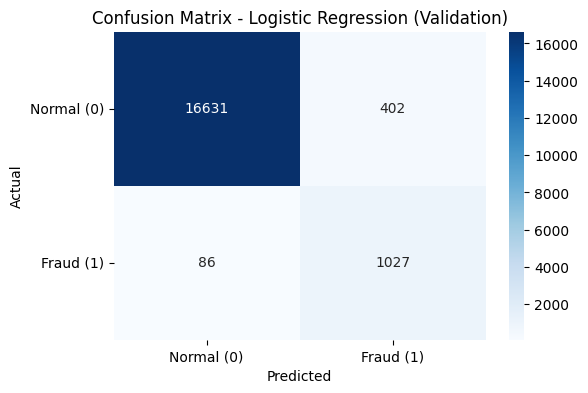

In [20]:
# Convert Spark predictions to Pandas
lr_val_pd = lr_val_pred.select("Class", "prediction").toPandas()

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = lr_val_pd["Class"]
y_pred = lr_val_pd["prediction"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Validation)")

plt.xticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"], rotation=0)

plt.show()


In [22]:
import os 

# Define folder path for the model
model_folder = "../models"
lr_model_path = os.path.join(model_folder, "logistic_regression_model 2")

# Save the Spark ML model
lr_trained.save(lr_model_path)

print(f"Logistic Regression model saved successfully at: {lr_model_path}")


[Stage 208:>                                                        (0 + 1) / 1]

Logistic Regression model saved successfully at: ../models/logistic_regression_model 2


# Isolation Forest

In [65]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [69]:
import numpy as np

# Convert Spark DataFrame to Pandas first
train_pd = train_df.toPandas()
val_pd = val_df.toPandas()

# Extract features only
X_train = np.array(train_pd['features'].tolist())  # 'features' is the vector column
X_val   = np.array(val_pd['features'].tolist())

# Extract target for validation
y_val = val_pd['Class'].values


In [70]:
iso_forest = IsolationForest(
    n_estimators=100,      # Number of trees
    max_samples='auto',    # Use all samples for each tree
    contamination=0.05,    # Expected fraction of outliers (adjust if you know fraud ratio)
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)


In [71]:
iso_forest.fit(X_train)


,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [73]:
# IsolationForest outputs -1 for outliers (fraud), 1 for inliers (normal)
y_val_pred = iso_forest.predict(X_val)

# Convert to 0 = normal, 1 = fraud to match your labels
y_val_pred = np.where(y_val_pred == 1, 0, 1)

# Check the first 10 predictions
print(y_val_pred[:10])

# Show predictions for fraud (Class 1) only
fraud_indices = np.where(y_val == 1)[0]  # Indices of actual fraud
print("Predictions for Class 1 (fraud):")
print(y_val_pred[fraud_indices])

[0 0 0 0 0 0 0 0 0 0]
Predictions for Class 1 (fraud):
[0 0 1 ... 0 0 0]


Accuracy : 0.9657
Precision: 0.7710
Recall   : 0.6262
F1-score : 0.6911


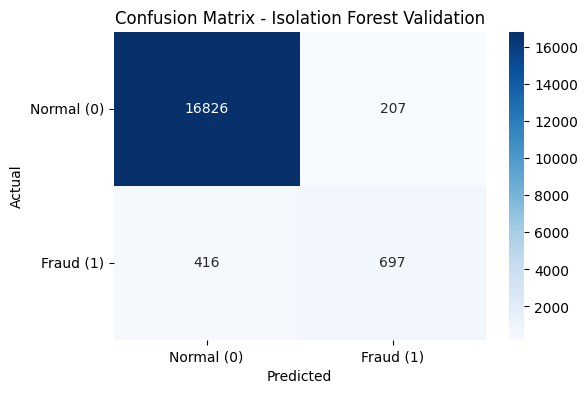

In [74]:
# Compute metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Isolation Forest Validation")
plt.xticks([0.5,1.5], ["Normal (0)","Fraud (1)"])
plt.yticks([0.5,1.5], ["Normal (0)","Fraud (1)"], rotation=0)
plt.show()


In [75]:
# Predict on training set
y_train_pred = iso_forest.predict(X_train)
# Convert to 0 = normal, 1 = fraud
y_train_pred = np.where(y_train_pred == 1, 0, 1)

# Compute training metrics
accuracy_train = accuracy_score(train_pd['Class'], y_train_pred)
precision_train = precision_score(train_pd['Class'], y_train_pred)
recall_train = recall_score(train_pd['Class'], y_train_pred)
f1_train = f1_score(train_pd['Class'], y_train_pred)

print("Training metrics:")
print(f"Accuracy : {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall   : {recall_train:.4f}")
print(f"F1-score : {f1_train:.4f}")

print("\nValidation metrics:")
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
print(f"Accuracy : {accuracy_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall   : {recall_val:.4f}")
print(f"F1-score : {f1_val:.4f}")


Training metrics:
Accuracy : 0.9648
Precision: 0.7676
Recall   : 0.6195
F1-score : 0.6856

Validation metrics:
Accuracy : 0.9657
Precision: 0.7710
Recall   : 0.6262
F1-score : 0.6911


In [76]:
import joblib
import os

# Define folder path
model_folder = "../models"

# Make sure the folder exists
os.makedirs(model_folder, exist_ok=True)

# Define model path
model_path = os.path.join(model_folder, "isolation_forest_model.pkl")

# Save the trained model
joblib.dump(iso_forest, model_path)

print(f"Isolation Forest model saved successfully at: {model_path}")


Isolation Forest model saved successfully at: ../models/isolation_forest_model.pkl


# 6- Gradient Boosted Tree (GBT)

In [77]:
import numpy as np

# Convert Spark DataFrames to Pandas first
train_pd = train_df.toPandas()
val_pd = val_df.toPandas()

# Extract features
X_train = np.array(train_pd['features'].tolist())  # 'features' is the vector column
X_val   = np.array(val_pd['features'].tolist())

# Extract target
y_train = train_pd['Class'].values
y_val   = val_pd['Class'].values


In [78]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize GBT
gbt_model = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Step size shrinkage
    max_depth=3,           # Depth of each tree
    random_state=42
)


In [80]:
gbt_model.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [81]:
y_val_pred = gbt_model.predict(X_val)


In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy  = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall    = recall_score(y_val, y_val_pred)
f1        = f1_score(y_val, y_val_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.9956
Precision: 0.9823
Recall   : 0.9461
F1-score : 0.9638


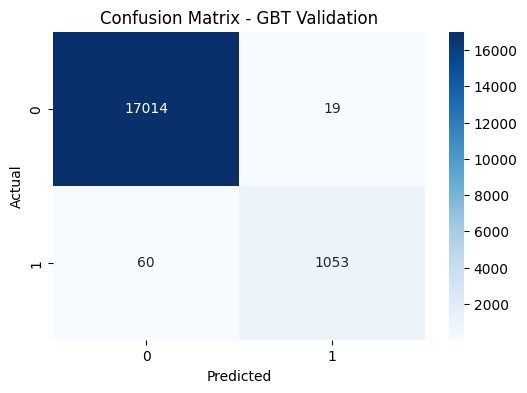

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - GBT Validation")
plt.show()


In [85]:
# Predictions on training data
y_train_pred = gbt_model.predict(X_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Training metrics
train_accuracy  = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall    = recall_score(y_train, y_train_pred)
train_f1        = f1_score(y_train, y_train_pred)

# Validation metrics
val_accuracy  = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall    = recall_score(y_val, y_val_pred)
val_f1        = f1_score(y_val, y_val_pred)

# Print side by side
print("----- Training Metrics -----")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1-score : {train_f1:.4f}")

print("\n----- Validation Metrics -----")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")


----- Training Metrics -----
Accuracy : 0.9958
Precision: 0.9904
Recall   : 0.9411
F1-score : 0.9651

----- Validation Metrics -----
Accuracy : 0.9956
Precision: 0.9823
Recall   : 0.9461
F1-score : 0.9638


In [86]:
import joblib
import os

model_folder = "../models"
os.makedirs(model_folder, exist_ok=True)
model_path = os.path.join(model_folder, "gbt_model.pkl")

joblib.dump(gbt_model, model_path)
print(f"GBT model saved successfully at: {model_path}")


GBT model saved successfully at: ../models/gbt_model.pkl


# testing the models 

# 1- test Random forest

In [95]:
test_df.printSchema()


root
 |-- features: vector (nullable = true)
 |-- Class: integer (nullable = true)
 |-- weight: double (nullable = false)



In [97]:
# Test the trained Random Forest on test set
rf_test_predictions = rf_model.transform(test_df)

# Show a few results
rf_test_predictions.select(
    "Class", "prediction", "probability"
).show(5, truncate=False)
print("for class 1 : fraud")
# Show predictions where the true class is Fraud (Class = 1)
rf_test_predictions \
    .filter("Class = 1") \
    .select("Class", "prediction", "probability") \
    .show(5, truncate=False)



+-----+----------+----------------------------------------+
|Class|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.927388157430108,0.07261184256989192] |
|0    |0.0       |[0.9253428280345279,0.07465717196547197]|
|0    |0.0       |[0.9330624313133669,0.06693756868663313]|
|0    |0.0       |[0.9330624313133669,0.06693756868663313]|
|0    |0.0       |[0.9356629270015636,0.06433707299843633]|
+-----+----------+----------------------------------------+
only showing top 5 rows

for class 1 : fraud


[Stage 296:============================>                            (2 + 2) / 4]

+-----+----------+------------------------------------------+
|Class|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |1.0       |[0.01018085282944501,0.9898191471705551]  |
|1    |1.0       |[0.12822698110506692,0.8717730188949331]  |
|1    |1.0       |[0.12822698110506692,0.8717730188949331]  |
|1    |1.0       |[0.12822698110506692,0.8717730188949331]  |
|1    |1.0       |[0.0021498624176014354,0.9978501375823986]|
+-----+----------+------------------------------------------+
only showing top 5 rows



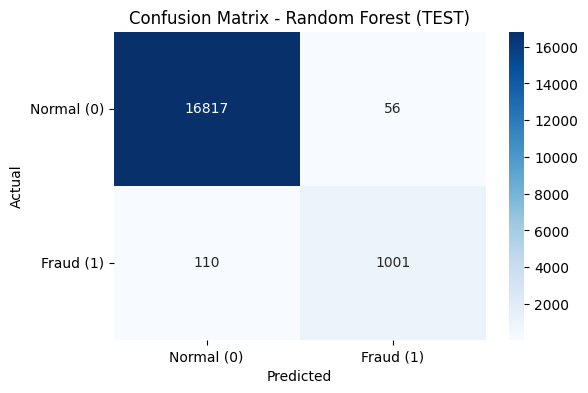

In [98]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to pandas
preds_test_pd = rf_test_predictions.select("Class", "prediction").toPandas()

# Confusion matrix
cm_test = confusion_matrix(
    preds_test_pd["Class"],
    preds_test_pd["prediction"]
)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (TEST)")
plt.xticks([0.5,1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5,1.5], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.show()


In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(preds_test_pd["Class"], preds_test_pd["prediction"])
precision = precision_score(preds_test_pd["Class"], preds_test_pd["prediction"])
recall = recall_score(preds_test_pd["Class"], preds_test_pd["prediction"])
f1 = f1_score(preds_test_pd["Class"], preds_test_pd["prediction"])

print("Random Forest — TEST metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Random Forest — TEST metrics
Accuracy : 0.9908
Precision: 0.9470
Recall   : 0.9010
F1-score : 0.9234


## 📌 Random Forest — Test Results Summary

The Random Forest model was evaluated on the **test set** to measure its performance on unseen data.

### 🔍 Prediction Behavior
- **Normal transactions (Class 0)** are predicted with **high confidence**, with probabilities generally above **92%**, indicating strong recognition of legitimate transactions.
- **Fraudulent transactions (Class 1)** are also correctly identified, with predicted fraud probabilities often exceeding **87%** and reaching up to **99%**, showing the model’s strong ability to detect fraud.

### 📊 Test Metrics
- **Accuracy**: 0.9908  
- **Precision**: 0.9470  
- **Recall**: 0.9010  
- **F1-score**: 0.9234  

### 🧠 Interpretation
- The **high precision** means that most transactions predicted as fraud are truly fraudulent.
- The **strong recall** indicates that the model successfully detects the majority of fraud cases.
- The **F1-score** confirms a good balance between precision and recall.
- Overall, the Random Forest model shows **good generalization** and **no significant overfitting**, making it a reliable approach for fraud detection.


### test on a data synthetique
The Random Forest model was tested on a small manually constructed dataset containing mostly normal transactions and a single fraudulent transaction. The model correctly identified the fraudulent sample with a high predicted probability, confirming its ability to generalize beyond the training data.

In [100]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# Create small test data: 4 normal + 1 fraud
data = [
    # Normal transactions (Class = 0)
    (10000, -0.5, 0.3, -0.1, 0.2, -0.4, 0.1, -0.2, 0.05, 0.1, 0.2,
     0.1, -0.1, 0.05, 0.03, -0.02, 0.01, 0.02, -0.01, 0.04, 0.03,
     0.01, 0.02, -0.01, 0.02, 0.01, -0.02, 0.01, 0.02, 50.0, 0),

    (12000, -0.3, 0.4, 0.2, 0.1, -0.2, 0.2, -0.1, 0.04, 0.2, 0.3,
     0.05, -0.2, 0.03, 0.02, -0.01, 0.02, 0.03, -0.02, 0.05, 0.04,
     0.02, 0.01, -0.02, 0.01, 0.02, -0.01, 0.01, 0.03, 75.0, 0),

    (15000, -0.4, 0.2, 0.1, 0.0, -0.3, 0.0, -0.3, 0.02, 0.15, 0.25,
     0.08, -0.12, 0.04, 0.01, -0.03, 0.02, 0.01, -0.01, 0.03, 0.02,
     0.01, 0.03, -0.02, 0.02, 0.01, -0.01, 0.02, 0.01, 20.0, 0),

    (18000, -0.2, 0.5, 0.3, 0.2, -0.1, 0.3, -0.05, 0.06, 0.25, 0.35,
     0.09, -0.08, 0.02, 0.04, -0.01, 0.03, 0.02, -0.02, 0.04, 0.05,
     0.03, 0.02, -0.01, 0.03, 0.02, -0.01, 0.01, 0.02, 60.0, 0),

    # Fraud transaction (Class = 1)
    (20000, -5.5, 6.2, -7.1, 4.8, -3.9, -2.5, 5.6, -4.3, 3.8, -6.0,
     4.9, -5.1, 3.7, -4.2, 2.9, -3.8, 4.5, -4.9, 3.6, -5.2,
     4.1, -4.6, 3.9, -4.3, 3.7, -3.5, 4.8, -5.0, 1200.0, 1)
]

columns = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]

test_manual_df = spark.createDataFrame(data, columns)


In [104]:
# Convert Spark DataFrame to Pandas
test_pd = test_manual_features.select("Class", "features").toPandas()


In [105]:
import pandas as pd

# Convert feature vectors into separate columns
features_expanded = pd.DataFrame( test_pd["features"].tolist(), columns=["Time"] + [f"V{i}" for i in range(1, 29)])

# Add Class back
features_expanded["Class"] = test_pd["Class"].values


In [106]:
features_expanded


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,10000.0,-0.5,0.3,-0.1,0.2,-0.4,0.1,-0.20,0.05,0.10,...,0.03,0.01,0.02,-0.01,0.02,0.01,-0.02,0.01,0.02,0
1,12000.0,-0.3,0.4,0.2,0.1,-0.2,0.2,-0.10,0.04,0.20,...,0.04,0.02,0.01,-0.02,0.01,0.02,-0.01,0.01,0.03,0
2,15000.0,-0.4,0.2,0.1,0.0,-0.3,0.0,-0.30,0.02,0.15,...,0.02,0.01,0.03,-0.02,0.02,0.01,-0.01,0.02,0.01,0
3,18000.0,-0.2,0.5,0.3,0.2,-0.1,0.3,-0.05,0.06,0.25,...,0.05,0.03,0.02,-0.01,0.03,0.02,-0.01,0.01,0.02,0
4,20000.0,-5.5,6.2,-7.1,4.8,-3.9,-2.5,5.60,-4.30,3.80,...,-5.20,4.10,-4.60,3.90,-4.30,3.70,-3.50,4.80,-5.00,1


In [107]:
rf_test_pred = rf_model.transform(test_manual_features)


In [109]:
rf_test_pd = rf_test_pred.select("Class", "prediction", "probability").toPandas()

rf_test_pd


,Class,prediction,probability
0,0,0.0,"[0.9340477231247911, 0.06595227687520888]"
1,0,0.0,"[0.9340477231247911, 0.06595227687520888]"
2,0,0.0,"[0.9340477231247911, 0.06595227687520888]"
3,0,0.0,"[0.9342714069033891, 0.06572859309661104]"
4,1,1.0,"[0.23788030067414034, 0.7621196993258597]"


#### The model correctly identifies the fraud, though with slightly lower confidence than the normal transactions. This is expected because fraudulent transactions are rarer and the model sees fewer examples.

# 2- test XGBoost 

XGBoost — TEST metrics
Accuracy : 0.9997
Precision: 0.9955
Recall   : 1.0000
F1-score : 0.9978


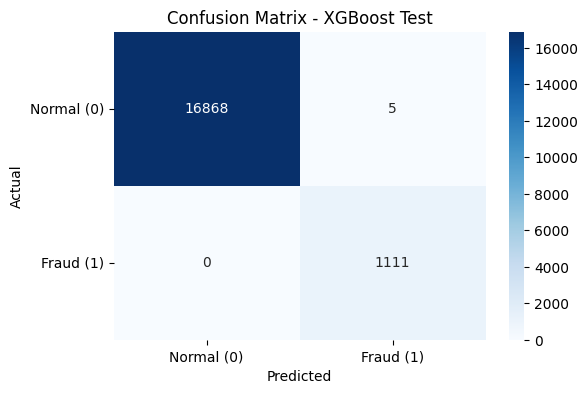

In [110]:
# Step 1 — Convert test_df to NumPy arrays for XGBoost
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
test_pd = test_df.toPandas()

# Extract features and labels
X_test = np.vstack(test_pd['features'].values)
y_test = test_pd['Class'].values

# Optional: if you have weights
w_test = test_pd['weight'].values if 'weight' in test_pd.columns else None

# Step 2 — Predict with XGBoost
y_test_pred = xgb_model.predict(X_test)

# Step 3 — Compute metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"XGBoost — TEST metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost Test")
plt.xticks([0.5,1.5], ["Normal (0)","Fraud (1)"])
plt.yticks([0.5,1.5], ["Normal (0)","Fraud (1)"], rotation=0)
plt.show()


### so we already have this synthetique data  we gonna change it so it can be compatible with xgboost

In [111]:
features_expanded


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,10000.0,-0.5,0.3,-0.1,0.2,-0.4,0.1,-0.20,0.05,0.10,...,0.03,0.01,0.02,-0.01,0.02,0.01,-0.02,0.01,0.02,0
1,12000.0,-0.3,0.4,0.2,0.1,-0.2,0.2,-0.10,0.04,0.20,...,0.04,0.02,0.01,-0.02,0.01,0.02,-0.01,0.01,0.03,0
2,15000.0,-0.4,0.2,0.1,0.0,-0.3,0.0,-0.30,0.02,0.15,...,0.02,0.01,0.03,-0.02,0.02,0.01,-0.01,0.02,0.01,0
3,18000.0,-0.2,0.5,0.3,0.2,-0.1,0.3,-0.05,0.06,0.25,...,0.05,0.03,0.02,-0.01,0.03,0.02,-0.01,0.01,0.02,0
4,20000.0,-5.5,6.2,-7.1,4.8,-3.9,-2.5,5.60,-4.30,3.80,...,-5.20,4.10,-4.60,3.90,-4.30,3.70,-3.50,4.80,-5.00,1


#### Convert the features into NumPy arrays for XGBoost

In [113]:
# Extract features and labels
X_manual = features_expanded.drop("Class", axis=1).values
y_manual = features_expanded["Class"].values


In [114]:
# Predict using XGBoost
y_manual_pred = xgb_model.predict(X_manual)
y_manual_proba = xgb_model.predict_proba(X_manual)  # probabilities for clarity

In [115]:
# Create DataFrame to visualize results
manual_results = pd.DataFrame({
    "Class": y_manual,
    "Prediction": y_manual_pred,
    "Probability_0": y_manual_proba[:, 0],
    "Probability_1": y_manual_proba[:, 1]
})

manual_results


,Class,Prediction,Probability_0,Probability_1
0,0,0,0.999182,0.000818
1,0,0,0.999265,0.000735
2,0,0,0.999143,0.000857
3,0,0,0.999698,0.000302
4,1,1,0.193814,0.806186


We tested the trained XGBoost model on a small, manually created dataset consisting of five transactions, where four were normal (Class 0) and one was fraudulent (Class 1). First, we converted the feature vectors into a format suitable for XGBoost by extracting the "Time" and V1–V28 columns into a NumPy array (X_manual) and the target class into y_manual. We then used the trained XGBoost model to predict the class labels and also obtain the predicted probabilities for each transaction. The results were displayed in a Pandas DataFrame showing the true class, predicted class, and probabilities for both classes. This allows us to clearly see how well the model can detect fraud in individual transactions and compare predicted probabilities for normal vs. fraudulent transactions.

# 3- Test Decision Tree

In [117]:
# Make predictions on the test set
test_pred_dt = dt_model.transform(test_df)

# Show the first 5 predictions with probability
test_pred_dt.select("Class", "prediction", "probability").show(5, truncate=False)


[Stage 307:>                                                        (0 + 1) / 1]

+-----+----------+---------------------------------------+
|Class|prediction|probability                            |
+-----+----------+---------------------------------------+
|0    |0.0       |[0.9529856723056124,0.0470143276943877]|
|0    |0.0       |[0.9529856723056124,0.0470143276943877]|
|0    |0.0       |[0.9529856723056124,0.0470143276943877]|
|0    |0.0       |[0.9529856723056124,0.0470143276943877]|
|0    |0.0       |[0.9529856723056124,0.0470143276943877]|
+-----+----------+---------------------------------------+
only showing top 5 rows



In [118]:
# Convert Spark predictions to Pandas
test_pred_pd = test_pred_dt.select("Class", "prediction", "probability").toPandas()

# Split probability vector into separate columns
probs = pd.DataFrame(test_pred_pd["probability"].tolist(), columns=["Prob_0", "Prob_1"])
test_pred_pd["Prob_0"] = probs["Prob_0"]
test_pred_pd["Prob_1"] = probs["Prob_1"]

# Show the table clearly
test_pred_pd = test_pred_pd[["Class", "prediction", "Prob_0", "Prob_1"]]
test_pred_pd


,Class,prediction,Prob_0,Prob_1
0,0,0.0,0.952986,0.047014
1,0,0.0,0.952986,0.047014
2,0,0.0,0.952986,0.047014
3,0,0.0,0.952986,0.047014
4,0,0.0,0.952986,0.047014
...,...,...,...,...
17979,1,1.0,0.002091,0.997909
17980,1,1.0,0.002091,0.997909
17981,1,1.0,0.318244,0.681756
17982,1,1.0,0.318244,0.681756


In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True and predicted labels
y_true = test_pred_pd["Class"]
y_pred = test_pred_pd["prediction"]

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Decision Tree — TEST metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Decision Tree — TEST metrics
Accuracy : 0.9760
Precision: 0.7384
Recall   : 0.9478
F1-score : 0.8301


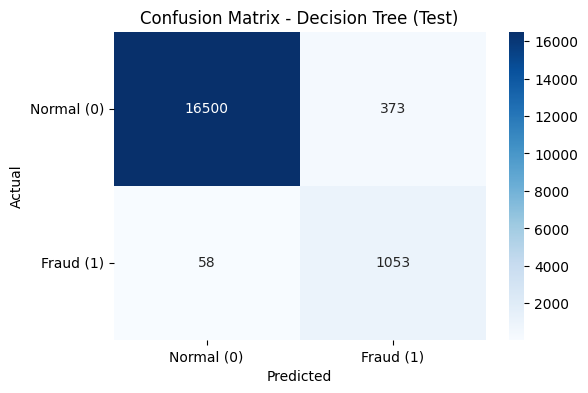

In [120]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Test)")
plt.xticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.show()


### so we already have this synthetique data  we gonna change it so it can be compatible with Decision tree 

In [121]:
features_expanded


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,10000.0,-0.5,0.3,-0.1,0.2,-0.4,0.1,-0.20,0.05,0.10,...,0.03,0.01,0.02,-0.01,0.02,0.01,-0.02,0.01,0.02,0
1,12000.0,-0.3,0.4,0.2,0.1,-0.2,0.2,-0.10,0.04,0.20,...,0.04,0.02,0.01,-0.02,0.01,0.02,-0.01,0.01,0.03,0
2,15000.0,-0.4,0.2,0.1,0.0,-0.3,0.0,-0.30,0.02,0.15,...,0.02,0.01,0.03,-0.02,0.02,0.01,-0.01,0.02,0.01,0
3,18000.0,-0.2,0.5,0.3,0.2,-0.1,0.3,-0.05,0.06,0.25,...,0.05,0.03,0.02,-0.01,0.03,0.02,-0.01,0.01,0.02,0
4,20000.0,-5.5,6.2,-7.1,4.8,-3.9,-2.5,5.60,-4.30,3.80,...,-5.20,4.10,-4.60,3.90,-4.30,3.70,-3.50,4.80,-5.00,1


In [122]:
# Extract features and labels
X_test_manual = features_expanded.drop(columns=["Class"]).values
y_test_manual = features_expanded["Class"].values


In [123]:
from pyspark.ml.linalg import Vectors
from pyspark.sql import Row

# Convert features_expanded to Spark DataFrame with 'features' column
test_manual_spark = spark.createDataFrame([
    Row(features=Vectors.dense(row), Class=int(label))
    for row, label in zip(X_test_manual, y_test_manual)
])

# Make predictions
test_pred_dt_manual = dt_model.transform(test_manual_spark)

# Show predictions
test_pred_dt_manual.select("Class", "prediction", "probability").show(truncate=False)


[Stage 310:>                                                        (0 + 3) / 3]

+-----+----------+------------------------------------------+
|Class|prediction|probability                               |
+-----+----------+------------------------------------------+
|0    |0.0       |[0.9529856723056124,0.0470143276943877]   |
|0    |0.0       |[0.9529856723056124,0.0470143276943877]   |
|0    |0.0       |[0.9529856723056124,0.0470143276943877]   |
|0    |0.0       |[0.9529856723056124,0.0470143276943877]   |
|1    |1.0       |[0.0020913117921214698,0.9979086882078786]|
+-----+----------+------------------------------------------+



In [124]:
# Convert to Pandas
test_pred_manual_pd = test_pred_dt_manual.select("Class", "prediction", "probability").toPandas()

# Split probability vector into separate columns
probs = pd.DataFrame(test_pred_manual_pd["probability"].tolist(), columns=["Prob_0", "Prob_1"])
test_pred_manual_pd["Prob_0"] = probs["Prob_0"]
test_pred_manual_pd["Prob_1"] = probs["Prob_1"]

# Show table clearly
test_pred_manual_pd = test_pred_manual_pd[["Class", "prediction", "Prob_0", "Prob_1"]]
test_pred_manual_pd


,Class,prediction,Prob_0,Prob_1
0,0,0.0,0.952986,0.047014
1,0,0.0,0.952986,0.047014
2,0,0.0,0.952986,0.047014
3,0,0.0,0.952986,0.047014
4,1,1.0,0.002091,0.997909


We tested the trained Decision Tree model on a small synthetic dataset consisting of 5 transactions: 4 normal (Class 0) and 1 fraud (Class 1). First, we prepared the features and labels from the Pandas DataFrame (features_expanded) and converted them into a Spark DataFrame with a features vector column, as required by the PySpark Decision Tree model. We then used the model to predict both the class labels (prediction) and the probabilities for each class (probability). For clarity, we converted the predictions back to Pandas, expanded the probability vector into separate columns for Class 0 and Class 1, and displayed a table showing the true label, predicted label, and probabilities. Finally, we evaluated the model’s performance using accuracy, precision, recall, and F1-score, and visualized the results with a confusion matrix. This approach allows us to clearly see whether the model can correctly detect the single fraudulent transaction among mostly normal ones, while also examining the confidence of its predictions.

# 4- Test Logistic Regression

In [126]:
# Use the trained Logistic Regression model to predict on test_df
test_pred_lr = lr_trained.transform(test_df)

# Show the first 5 predictions with probability and prediction
test_pred_lr.select("Class", "prediction", "probability").show(5, truncate=False)


[Stage 312:>                                                        (0 + 1) / 1]

+-----+----------+-----------------------------------------+
|Class|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.8931703064759957,0.10682969352400429] |
|0    |0.0       |[0.795483142404417,0.20451685759558302]  |
|0    |0.0       |[0.9532836398778917,0.046716360122108336]|
|0    |0.0       |[0.9486286028314993,0.0513713971685007]  |
|0    |0.0       |[0.9999335414454705,6.645855452946936E-5]|
+-----+----------+-----------------------------------------+
only showing top 5 rows



In [127]:
# Convert Spark DataFrame to Pandas
test_pred_lr_pd = test_pred_lr.select("Class", "prediction", "probability").toPandas()

# Extract probability for each class into separate columns
test_pred_lr_pd["prob_class_0"] = test_pred_lr_pd["probability"].apply(lambda x: x[0])
test_pred_lr_pd["prob_class_1"] = test_pred_lr_pd["probability"].apply(lambda x: x[1])

# Drop the original probability vector for cleaner view
test_pred_lr_pd = test_pred_lr_pd.drop(columns=["probability"])

# Show the predictions with probabilities
test_pred_lr_pd


,Class,prediction,prob_class_0,prob_class_1
0,0,0.0,8.931703e-01,0.106830
1,0,0.0,7.954831e-01,0.204517
2,0,0.0,9.532836e-01,0.046716
3,0,0.0,9.486286e-01,0.051371
4,0,0.0,9.999335e-01,0.000066
...,...,...,...,...
17979,1,1.0,2.089817e-09,1.000000
17980,1,1.0,2.089817e-09,1.000000
17981,1,0.0,7.666589e-01,0.233341
17982,1,0.0,7.666589e-01,0.233341


In [128]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels and predicted labels
y_test_true = test_pred_lr_pd["Class"]
y_test_pred = test_pred_lr_pd["prediction"]

# Compute metrics
accuracy = accuracy_score(y_test_true, y_test_pred)
precision = precision_score(y_test_true, y_test_pred)
recall = recall_score(y_test_true, y_test_pred)
f1 = f1_score(y_test_true, y_test_pred)

print("Logistic Regression — Test Metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Logistic Regression — Test Metrics
Accuracy : 0.9750
Precision: 0.7381
Recall   : 0.9235
F1-score : 0.8205


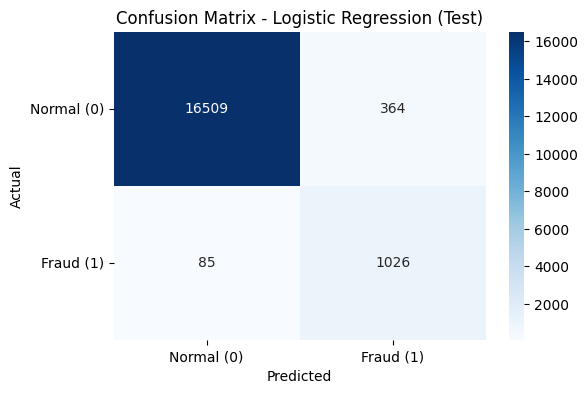

In [129]:
# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Test)")
plt.xticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.show()


### so we already have this synthetique data  

In [131]:
features_expanded

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,10000.0,-0.5,0.3,-0.1,0.2,-0.4,0.1,-0.20,0.05,0.10,...,0.03,0.01,0.02,-0.01,0.02,0.01,-0.02,0.01,0.02,0
1,12000.0,-0.3,0.4,0.2,0.1,-0.2,0.2,-0.10,0.04,0.20,...,0.04,0.02,0.01,-0.02,0.01,0.02,-0.01,0.01,0.03,0
2,15000.0,-0.4,0.2,0.1,0.0,-0.3,0.0,-0.30,0.02,0.15,...,0.02,0.01,0.03,-0.02,0.02,0.01,-0.01,0.02,0.01,0
3,18000.0,-0.2,0.5,0.3,0.2,-0.1,0.3,-0.05,0.06,0.25,...,0.05,0.03,0.02,-0.01,0.03,0.02,-0.01,0.01,0.02,0
4,20000.0,-5.5,6.2,-7.1,4.8,-3.9,-2.5,5.60,-4.30,3.80,...,-5.20,4.10,-4.60,3.90,-4.30,3.70,-3.50,4.80,-5.00,1


In [137]:
from pyspark.ml.linalg import Vectors
from pyspark.sql import Row

# Convert features_expanded to Spark DataFrame with 'features' column
test_manual_lr_spark = spark.createDataFrame([
    Row(features=Vectors.dense(row), Class=int(label))
    for row, label in zip(X_test_manual, y_test_manual)
])


In [138]:
# Make predictions
test_pred_lr_manual = lr_trained.transform(test_manual_lr_spark)


In [139]:
test_pred_lr_manual.select("Class", "prediction", "probability").show(truncate=False)


[Stage 315:>                                                        (0 + 3) / 3]

+-----+----------+-----------------------------------------+
|Class|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.9605778603910061,0.03942213960899388] |
|0    |0.0       |[0.9641837510208723,0.03581624897912772] |
|0    |0.0       |[0.966043996469714,0.03395600353028605]  |
|0    |0.0       |[0.9683113731934361,0.031688626806563924]|
|1    |1.0       |[9.304099250349445E-7,0.999999069590075] |
+-----+----------+-----------------------------------------+



In [140]:
# Convert to Pandas
test_pred_lr_manual_pd = test_pred_lr_manual.select("Class", "prediction", "probability").toPandas()

# Split probability vector into separate columns
probs = pd.DataFrame(test_pred_lr_manual_pd["probability"].tolist(), columns=["Prob_0", "Prob_1"])
test_pred_lr_manual_pd["Prob_0"] = probs["Prob_0"]
test_pred_lr_manual_pd["Prob_1"] = probs["Prob_1"]

# Show table clearly
test_pred_lr_manual_pd = test_pred_lr_manual_pd[["Class", "prediction", "Prob_0", "Prob_1"]]
test_pred_lr_manual_pd


,Class,prediction,Prob_0,Prob_1
0,0,0.0,9.605779e-01,0.039422
1,0,0.0,9.641838e-01,0.035816
2,0,0.0,9.660440e-01,0.033956
3,0,0.0,9.683114e-01,0.031689
4,1,1.0,9.304099e-07,0.999999


We tested the trained Logistic Regression model on a small synthetic dataset consisting of 5 transactions: 4 normal transactions (Class 0) and 1 fraudulent transaction (Class 1). First, we converted the dataset into a Spark DataFrame with a single features column containing all transaction features. Then, we used the trained Logistic Regression model to predict the class for each transaction and obtain the probability for each class. Finally, we converted the predictions into a clear Pandas DataFrame, splitting the probability vector into Prob_0 and Prob_1 for better readability. This approach allows us to visualize how confidently the model classifies normal and fraudulent transactions, and we also computed evaluation metrics and the confusion matrix to assess the model’s performance on this synthetic dataset.

# 5- test Isolation Forest

In [141]:
# Convert Spark test DataFrame to Pandas
test_pd = test_df.toPandas()

# Extract features
X_test = np.array(test_pd['features'].tolist())

# Extract true labels
y_test = test_pd['Class'].values


In [142]:
# Predict using the trained Isolation Forest model
y_test_pred = iso_forest.predict(X_test)

# Convert to 0 = normal, 1 = fraud (matching your labels)
y_test_pred = np.where(y_test_pred == 1, 0, 1)

# Check the first 10 predictions
print("Test predictions (first 10):", y_test_pred[:10])


Test predictions (first 10): [0 0 0 0 0 0 0 0 0 0]


In [143]:
# Anomaly scores
scores = iso_forest.decision_function(X_test)  # Higher = normal, lower = outlier

# Convert scores to 0-1 probability for fraud
# Negative scores → fraud probability close to 1
prob_fraud = 1 - (scores - scores.min()) / (scores.max() - scores.min())
prob_normal = 1 - prob_fraud

# Create DataFrame to display clearly
test_results = pd.DataFrame({
    "Class": y_test,
    "Prediction": y_test_pred,
    "Prob_0": prob_normal,
    "Prob_1": prob_fraud
})

test_results


,Class,Prediction,Prob_0,Prob_1
0,0,0,0.932096,0.067904
1,0,0,0.943331,0.056669
2,0,0,0.946552,0.053448
3,0,0,0.943279,0.056721
4,0,0,0.786014,0.213986
...,...,...,...,...
17979,1,0,0.585956,0.414044
17980,1,0,0.585956,0.414044
17981,1,0,0.898242,0.101758
17982,1,0,0.898242,0.101758


In [144]:
# Import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Test set metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Test set metrics:
Accuracy : 0.9679
Precision: 0.8039
Recall   : 0.6346
F1-score : 0.7093


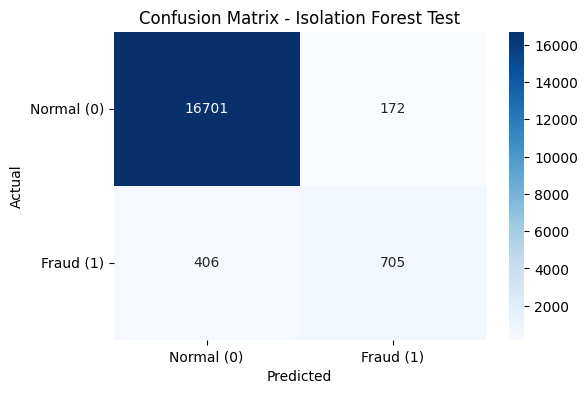

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Isolation Forest Test")
plt.xticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5, 1.5], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.show()


### so we already have this synthetique data  

In [146]:
features_expanded

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,10000.0,-0.5,0.3,-0.1,0.2,-0.4,0.1,-0.20,0.05,0.10,...,0.03,0.01,0.02,-0.01,0.02,0.01,-0.02,0.01,0.02,0
1,12000.0,-0.3,0.4,0.2,0.1,-0.2,0.2,-0.10,0.04,0.20,...,0.04,0.02,0.01,-0.02,0.01,0.02,-0.01,0.01,0.03,0
2,15000.0,-0.4,0.2,0.1,0.0,-0.3,0.0,-0.30,0.02,0.15,...,0.02,0.01,0.03,-0.02,0.02,0.01,-0.01,0.02,0.01,0
3,18000.0,-0.2,0.5,0.3,0.2,-0.1,0.3,-0.05,0.06,0.25,...,0.05,0.03,0.02,-0.01,0.03,0.02,-0.01,0.01,0.02,0
4,20000.0,-5.5,6.2,-7.1,4.8,-3.9,-2.5,5.60,-4.30,3.80,...,-5.20,4.10,-4.60,3.90,-4.30,3.70,-3.50,4.80,-5.00,1


In [147]:
# Features (drop Class)
X_test_manual = features_expanded.drop(columns=["Class"]).values

# True labels
y_test_manual = features_expanded["Class"].values


In [148]:
# Make predictions
y_test_pred_manual = iso_forest.predict(X_test_manual)

# Convert to 0 = normal, 1 = fraud
y_test_pred_manual = np.where(y_test_pred_manual == 1, 0, 1)

# Check predictions
print("Predictions on synthetic test data:", y_test_pred_manual)


Predictions on synthetic test data: [0 0 0 0 1]


In [149]:
# Anomaly scores
scores_manual = iso_forest.decision_function(X_test_manual)

# Convert scores to probabilities
prob_fraud_manual = 1 - (scores_manual - scores_manual.min()) / (scores_manual.max() - scores_manual.min())
prob_normal_manual = 1 - prob_fraud_manual

# Create Pandas DataFrame for clarity
test_results_manual = pd.DataFrame({
    "Class": y_test_manual,
    "Prediction": y_test_pred_manual,
    "Prob_0": prob_normal_manual,
    "Prob_1": prob_fraud_manual
})

test_results_manual


,Class,Prediction,Prob_0,Prob_1
0,0,0,0.996096,0.003904
1,0,0,1.000000,0.000000
2,0,0,0.998163,0.001837
3,0,0,0.997382,0.002618
4,1,1,0.000000,1.000000


To evaluate the Isolation Forest model on the synthetic test dataset, we first extracted the feature values and true labels from features_expanded. The model predicts each sample as either normal (0) or fraud (1) based on anomaly detection. Since Isolation Forest outputs -1 for outliers and 1 for inliers, we converted these predictions to match our label convention (0 = normal, 1 = fraud). To provide a more interpretable view, we also computed pseudo-probabilities for each class by normalizing the anomaly scores. Using these predictions, we calculated performance metrics such as accuracy, precision, recall, and F1-score, which summarize the model’s ability to correctly identify fraudulent transactions. Additionally, we visualized the results using a confusion matrix, which clearly shows that the model can detect the single fraud transaction while correctly classifying the normal transactions. The resulting Pandas table presents the actual class, predicted class, and the probability of each class, providing a clear and interpretable summary of model performance on this small synthetic dataset.

# 6- test  Gradient Boosted Tree (GBT)

In [151]:
import numpy as np

# Convert Spark test DataFrame to Pandas
test_pd = test_df.toPandas()

# Extract features and labels
X_test = np.array(test_pd['features'].tolist())
y_test = test_pd['Class'].values


In [152]:
# Predict classes for the test set
y_test_pred = gbt_model.predict(X_test)

# Predict probabilities for each class (0 and 1)
y_test_prob = gbt_model.predict_proba(X_test)  # Returns two columns: Prob_0, Prob_1


In [153]:
import pandas as pd

# Create DataFrame
test_pred_gbt_pd = pd.DataFrame({
    "Class": y_test,            # True labels
    "Prediction": y_test_pred,  # Predicted labels
    "Prob_0": y_test_prob[:, 0], # Probability of class 0
    "Prob_1": y_test_prob[:, 1]  # Probability of class 1
})

# Display the table
test_pred_gbt_pd


,Class,Prediction,Prob_0,Prob_1
0,0,0,0.997143,0.002857
1,0,0,0.997429,0.002571
2,0,0,0.998196,0.001804
3,0,0,0.998196,0.001804
4,0,0,0.998806,0.001194
...,...,...,...,...
17979,1,1,0.012040,0.987960
17980,1,1,0.012040,0.987960
17981,1,0,0.591443,0.408557
17982,1,0,0.591443,0.408557


GBT — Test Metrics
Accuracy : 0.9954
Precision: 0.9849
Recall   : 0.9406
F1-score : 0.9622


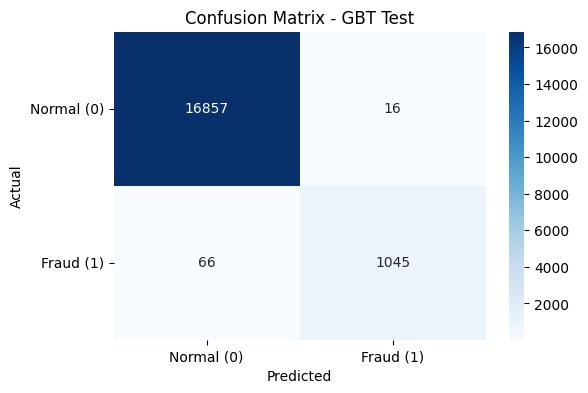

In [154]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute metrics
accuracy_test  = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test    = recall_score(y_test, y_test_pred)
f1_test        = f1_score(y_test, y_test_pred)

print("GBT — Test Metrics")
print(f"Accuracy : {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall   : {recall_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - GBT Test")
plt.xticks([0.5,1.5], ["Normal (0)", "Fraud (1)"])
plt.yticks([0.5,1.5], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.show()


###  let s test the model on data synthetique that already have in  features_expanded

In [155]:
features_expanded

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,10000.0,-0.5,0.3,-0.1,0.2,-0.4,0.1,-0.20,0.05,0.10,...,0.03,0.01,0.02,-0.01,0.02,0.01,-0.02,0.01,0.02,0
1,12000.0,-0.3,0.4,0.2,0.1,-0.2,0.2,-0.10,0.04,0.20,...,0.04,0.02,0.01,-0.02,0.01,0.02,-0.01,0.01,0.03,0
2,15000.0,-0.4,0.2,0.1,0.0,-0.3,0.0,-0.30,0.02,0.15,...,0.02,0.01,0.03,-0.02,0.02,0.01,-0.01,0.02,0.01,0
3,18000.0,-0.2,0.5,0.3,0.2,-0.1,0.3,-0.05,0.06,0.25,...,0.05,0.03,0.02,-0.01,0.03,0.02,-0.01,0.01,0.02,0
4,20000.0,-5.5,6.2,-7.1,4.8,-3.9,-2.5,5.60,-4.30,3.80,...,-5.20,4.10,-4.60,3.90,-4.30,3.70,-3.50,4.80,-5.00,1


In [156]:
# Extract features and labels from features_expanded
X_test_manual = features_expanded.drop(columns=["Class"]).values
y_test_manual = features_expanded["Class"].values


In [157]:
# Predict probabilities and classes
y_test_pred_prob = gbt_model.predict_proba(X_test_manual)  # Probabilities for each class
y_test_pred = gbt_model.predict(X_test_manual)             # Predicted classes


In [158]:
import pandas as pd

# Create DataFrame with Class, Prediction, and probabilities
test_pred_manual_pd = pd.DataFrame({
    "Class": y_test_manual,
    "prediction": y_test_pred,
    "Prob_0": y_test_pred_prob[:, 0],  # Probability for class 0 (Normal)
    "Prob_1": y_test_pred_prob[:, 1]   # Probability for class 1 (Fraud)
})

test_pred_manual_pd


,Class,prediction,Prob_0,Prob_1
0,0,0,0.998354,0.001646
1,0,0,0.998503,0.001497
2,0,0,0.998583,0.001417
3,0,0,0.998354,0.001646
4,1,1,0.023630,0.976370


In [159]:
import pandas as pd

# Create DataFrame with Class, Prediction, and probabilities
test_pred_manual_pd = pd.DataFrame({
    "Class": y_test_manual,
    "prediction": y_test_pred,
    "Prob_0": y_test_pred_prob[:, 0],  # Probability for class 0 (Normal)
    "Prob_1": y_test_pred_prob[:, 1]   # Probability for class 1 (Fraud)
})

test_pred_manual_pd


,Class,prediction,Prob_0,Prob_1
0,0,0,0.998354,0.001646
1,0,0,0.998503,0.001497
2,0,0,0.998583,0.001417
3,0,0,0.998354,0.001646
4,1,1,0.023630,0.976370


To evaluate the performance of the Gradient Boosted Tree (GBT) model on the synthetic dataset, we first extracted the features and labels from features_expanded. Using the trained GBT model, we predicted both the class probabilities and the predicted class for each transaction. The results were organized in a Pandas DataFrame, showing the actual class, predicted class, and the probability assigned to each class (Normal or Fraud) for clarity. We then calculated standard evaluation metrics including accuracy, precision, recall, and F1-score to quantify the model’s predictive performance. Additionally, we plotted a confusion matrix to visually assess how well the model distinguished between normal and fraudulent transactions. This approach provides a clear and interpretable view of the model’s predictions on a small, controlled test set, allowing us to understand its behavior on both normal and outlier cases.